**Problem Statement: Face Mask Detection using CNN**

The goal of this project is to develop a deep learning model using Convolutional Neural
Networks (CNN) that can automatically detect whether a person in an image or video is
wearing a face mask or not.

This system can be used in real-world scenarios such as:

- Public places (airports, malls, hospitals)

- Surveillance systems

- Entry control systems for safety compliance

The model should take an input image (or video frame) and classify it into:

- With Mask

- Without Mask

In [1]:
!pip install kagglehub tensorflow opencv-python matplotlib scikit-learn

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
import kagglehub

path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Dataset path: /kaggle/input/face-mask-dataset


In [5]:
import os

for root, dirs, files in os.walk(path):
    print("Current Path:", root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-"*40)

Current Path: /kaggle/input/face-mask-dataset
Folders: ['data']
Files: 0
----------------------------------------
Current Path: /kaggle/input/face-mask-dataset/data
Folders: ['without_mask', 'with_mask']
Files: 0
----------------------------------------
Current Path: /kaggle/input/face-mask-dataset/data/without_mask
Folders: []
Files: 3828
----------------------------------------
Current Path: /kaggle/input/face-mask-dataset/data/with_mask
Folders: []
Files: 3725
----------------------------------------


In [6]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

data = []
labels = []

# ✅ Correct base path
base_path = os.path.join(path, "data")

categories = ["with_mask", "without_mask"]

for category in categories:
    folder = os.path.join(base_path, category)   # ✅ fixed here
    label = categories.index(category)

    for img in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img)
            image = cv2.imread(img_path)

            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            data.append(image)
            labels.append(label)

        except Exception as e:
            pass

# Convert to numpy
X = np.array(data) / 255.0
y = np.array(labels)

print("Loaded images:", len(X))

Loaded images: 7553


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8145 - loss: 0.4083 - val_accuracy: 0.8773 - val_loss: 0.2869
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.8888 - loss: 0.2822 - val_accuracy: 0.8906 - val_loss: 0.2476
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9056 - loss: 0.2374 - val_accuracy: 0.9073 - val_loss: 0.2216
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9126 - loss: 0.2195 - val_accuracy: 0.7432 - val_loss: 0.7265
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9160 - loss: 0.2057 - val_accuracy: 0.9373 - val_loss: 0.1956
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9264 - loss: 0.1919 - val_accuracy: 0.9382 - val_loss: 0.1616
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9336 - loss: 0.1815 - val_accuracy: 0.9532 - val_loss: 0.1440
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9416 - loss: 0.1598 - val_accu

In [11]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step - accuracy: 0.9453 - loss: 0.1484
Test Accuracy: 0.9452780485153198


In [12]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step
[[576  16]
 [ 46 495]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       592
           1       0.97      0.91      0.94       541

    accuracy                           0.95      1133
   macro avg       0.95      0.94      0.94      1133
weighted avg       0.95      0.95      0.95      1133



In [13]:
model.save("face_mask_model.h5")

In [18]:
import os

folder = "/kaggle/input/face-mask-dataset/data/with_mask"
print(os.listdir(folder)[:10])  # show first 10 images

['with_mask_3326.jpg', 'with_mask_3139.jpg', 'with_mask_696.jpg', 'with_mask_2867.jpg', 'with_mask_39.jpg', 'with_mask_1811.jpg', 'with_mask_532.jpg', 'with_mask_1619.jpg', 'with_mask_3471.jpg', 'with_mask_3501.jpg']


In [19]:
img_path = "/kaggle/input/face-mask-dataset/data/with_mask/with_mask_39.jpg"

In [20]:
import cv2
import numpy as np
import os
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("face_mask_model.h5")

# Correct folder
folder = "/kaggle/input/face-mask-dataset/data/with_mask"

# Pick one real image
img_name = "with_mask_3326.jpg"   # ✅ from your list
img_path = os.path.join(folder, img_name)

print("Using image:", img_path)

# Read image
img = cv2.imread(img_path)

if img is None:
    print("❌ Error: Image not loaded")
else:
    # Preprocess
    img_resized = cv2.resize(img, (128,128))
    img_resized = img_resized / 255.0
    img_resized = np.reshape(img_resized, (1,128,128,3))

    # Predict
    pred = model.predict(img_resized)

    label = "Mask 😷" if pred < 0.5 else "No Mask ❌"

    print("Prediction:", label)

Using image: /kaggle/input/face-mask-dataset/data/with_mask/with_mask_3326.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Prediction: Mask 😷


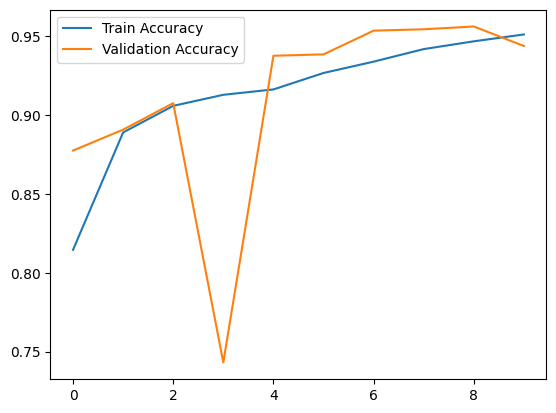

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()